In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure

In [2]:
def calculateECC(magnitudeReponse, thresholds = 100):
    #normalize the magnitude to {0,1} for consistent thresholding
    magMin = np.min(magnitudeReponse)
    magMax = np.max(magnitudeReponse)
    magNorm = (magnitudeReponse - magMin) / (magMax - magMin)

    ecValues = []
    tSpace = np.linspace(0, 1, thresholds)

    for t in tSpace:
        #binarize the magnitude response at threshold t
        binaryImage = magNorm > t

        ec = measure.euler_number(binaryImage, connectivity = 2)
        ecValues.append(ec)

    return tSpace, ecValues

def generateTopologicalSignature(csvFile):
    df = pd.read_csv(csvFile)
    kernels = df.values.reshape(-1, 3, 3)

    #using the indices from the spectral analysis of multiple kernels file
    idxVulnerable = 806
    idxRobust = 42

    plt.figure(figsize=(10, 6))

    for idx, label in [(idxVulnerable, 'Vulnerable (806)'), (idxRobust, 'Robust (42)')]:
        h = kernels[idx]
        H = np.abs(np.fft.fftshift(np.fft.fft2(h, s=(128,128))))
        thresholds, ecValues = calculateECC(H)

        plt.plot(thresholds, ecValues, label=f"Kernel {label}", linewidth = 2.5)
    plt.title("Topological Signature (Euler Characteristic Curve)") 
    plt.xlabel("Threshold (Magnitude Normalized)") 
    plt.ylabel("Euler Characteristic ($\chi$)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("topological_signature.png")
    plt.show()



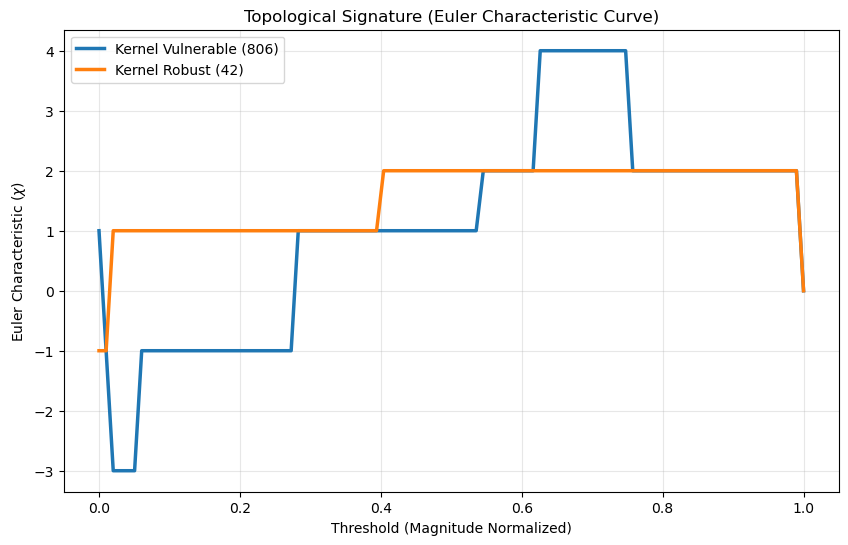

In [ ]:
generateTopologicalSignature("resnet18_layer1_3x3.csv")